# Recommendation Models — Retailrocket E-commerce Dataset



In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import TruncatedSVD

from src.config import ASSETS_DIR, PROCESSED_FILES, MODEL_CONFIG
from src.recommender import (
    PopularityRecommender, ContentBasedRecommender,
    CollaborativeFilteringRecommender, HybridRecommender,
    train_and_save_all_models,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
MODEL_ASSETS = ASSETS_DIR / "models"
MODEL_ASSETS.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 50)

item_features = pd.read_parquet(PROCESSED_FILES["item_features"])
category_tree = pd.read_parquet(PROCESSED_FILES["category_tree_clean"])
events = pd.read_parquet(PROCESSED_FILES["events_clean"])
user_id_map = pd.read_parquet(PROCESSED_FILES["user_id_map"])
item_id_map = pd.read_parquet(PROCESSED_FILES["item_id_map"])
user_features = pd.read_parquet(PROCESSED_FILES["user_features"])

print(f"{len(item_features):,} items | {len(user_id_map):,} users | {len(events):,} events")


3,000 items | 3,999 users | 122,162 events


## 1. Popularity-Based Recommendation



In [2]:
popularity_model = PopularityRecommender(item_features, events).fit()

print("Trending (recency-weighted):")
display(popularity_model.trending(5))

print("\nBest Sellers (all-time transaction count):")
display(popularity_model.best_sellers(5))

print("\nRecently Popular (last 7 days, raw count):")
display(popularity_model.recently_popular(5))


2026-07-25 06:34:52 | INFO     | src.recommender | PopularityRecommender.fit completed in 0.00s


Trending (recency-weighted):


,itemid,categoryid,product_interaction_score,item_view_count,product_conversion_rate
0,23,1040.0,1.0,311.0,0.028939
1,3000,1092.0,1.0,611.0,0.050736
2,1,1033.0,1.0,45120.0,0.040027
3,3,1029.0,1.0,7812.0,0.036738
4,2,1060.0,1.0,14945.0,0.038341



Best Sellers (all-time transaction count):


,itemid,categoryid,item_transaction_count,product_conversion_rate
0,1,1033.0,1806.0,0.040027
1,2,1060.0,573.0,0.038341
2,3,1029.0,287.0,0.036738
3,4,1078.0,229.0,0.047178
4,5,1009.0,145.0,0.041691



Recently Popular (last 7 days, raw count):


,itemid,recent_event_count,categoryid
0,1,3053,1033.0
1,2,1044,1060.0
2,3,535,1029.0
3,4,338,1078.0
4,5,235,1009.0


**"Trending" vs. "Best Sellers" are deliberately different signals** —
below we check how much the two rankings actually agree. A high overlap
would mean we're building two features that just show the same list twice.


In [3]:
top_n = 50
trending_top = set(popularity_model.trending(top_n)["itemid"])
best_sellers_top = set(popularity_model.best_sellers(top_n)["itemid"])
overlap = len(trending_top & best_sellers_top)
print(f"Overlap between top-{top_n} 'Trending' and top-{top_n} 'Best Sellers': "
      f"{overlap}/{top_n} items ({overlap/top_n:.0%})")


Overlap between top-50 'Trending' and top-50 'Best Sellers': 23/50 items (46%)


## 2. Content-Based Filtering



In [4]:
content_model = ContentBasedRecommender(item_features, category_tree).fit()

sample_item = int(item_features.loc[item_features["item_view_count"] > 0, "itemid"].iloc[0])
sample_cat = item_features.loc[item_features["itemid"] == sample_item, "categoryid"].iloc[0]
print(f"Seed item: {sample_item} (category {sample_cat})")

similar = content_model.similar_items(sample_item, n=5)
display(similar)

print()
for _, row in similar.iterrows():
    print(f"  item {int(row['itemid'])}: {content_model.explain(sample_item, int(row['itemid']))}")


2026-07-25 06:34:52 | INFO     | src.recommender | ContentBasedRecommender: no usable brand column found (Retailrocket does not label one) — brand similarity is architecturally supported but inactive for this dataset.


2026-07-25 06:34:52 | INFO     | src.recommender | ContentBasedRecommender: fit TF-IDF over 3000 items, vocabulary size 126


2026-07-25 06:34:52 | INFO     | src.recommender | ContentBasedRecommender.fit completed in 0.18s


Seed item: 1 (category 1033.0)


,itemid,content_similarity
0,2641,1.00000
1,1475,1.00000
2,1433,1.00000
3,501,1.00000
4,1601,0.86729



  item 2641: Recommended because it has same category and similar price range to an item you viewed.
  item 1475: Recommended because it has same category and similar price range to an item you viewed.
  item 1433: Recommended because it has same category and similar price range to an item you viewed.
  item 501: Recommended because it has same category and similar price range to an item you viewed.
  item 1601: Recommended because it has same category and similar price range to an item you viewed.


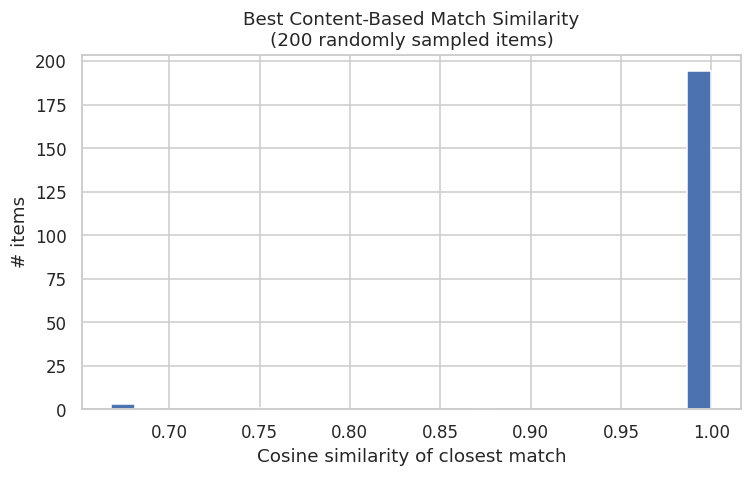

In [5]:
# Distribution of top-1 content similarity across a random sample of items —
# tells us how "tight" the content neighborhoods generally are.
rng = np.random.default_rng(42)
sample_ids = rng.choice(item_features["itemid"].unique(), size=200, replace=False)
top1_sims = []
for iid in sample_ids:
    sims = content_model.similar_items(int(iid), n=1)
    if len(sims):
        top1_sims.append(sims.iloc[0]["content_similarity"])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(top1_sims, bins=25, color="#4C72B0")
ax.set_title("Best Content-Based Match Similarity\n(200 randomly sampled items)")
ax.set_xlabel("Cosine similarity of closest match")
ax.set_ylabel("# items")
plt.tight_layout()
plt.savefig(MODEL_ASSETS / "01_content_similarity_distribution.png", bbox_inches="tight")
plt.show()


## 3. Collaborative Filtering




In [6]:
cf_model = CollaborativeFilteringRecommender(
    events, n_users=len(user_id_map), n_items=len(item_id_map)
).fit()

sparsity = 1 - cf_model.interaction_matrix.nnz / (cf_model.n_users * cf_model.n_items)
print(f"Interaction matrix: {cf_model.n_users:,} users x {cf_model.n_items:,} items")
print(f"Sparsity: {sparsity:.4%}  ({cf_model.interaction_matrix.nnz:,} non-zero entries)")
print(f"Users excluded from CF (below min_interactions threshold): {len(cf_model.excluded_users):,} "
      f"({len(cf_model.excluded_users)/cf_model.n_users:.1%})")
print(f"Items excluded from CF (below min_interactions threshold): {len(cf_model.excluded_items):,} "
      f"({len(cf_model.excluded_items)/cf_model.n_items:.1%})")


2026-07-25 06:34:53 | INFO     | src.recommender | CF interaction matrix: 3999 users x 1914 items, 39149 nonzero entries | 6 users and 522 items below the min-interaction threshold (excluded from CF, routed to hybrid fallback instead)


2026-07-25 06:34:53 | INFO     | src.recommender | CollaborativeFilteringRecommender._build_interaction_matrix completed in 0.09s


2026-07-25 06:34:53 | INFO     | src.recommender | SVD: 50 factors explain 99.8% of variance


2026-07-25 06:34:53 | INFO     | src.recommender | CollaborativeFilteringRecommender.fit completed in 0.16s


Interaction matrix: 3,999 users x 1,914 items
Sparsity: 99.4885%  (39,149 non-zero entries)
Users excluded from CF (below min_interactions threshold): 6 (0.2%)
Items excluded from CF (below min_interactions threshold): 522 (27.3%)


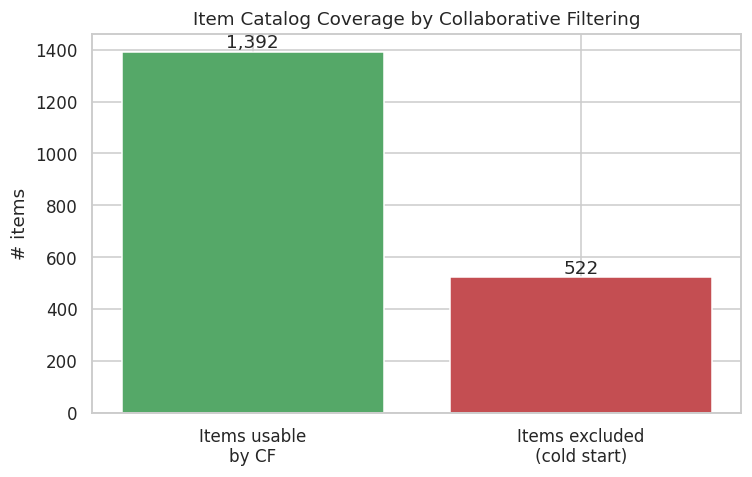

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
categories = ["Items usable\nby CF", "Items excluded\n(cold start)"]
values = [cf_model.n_items - len(cf_model.excluded_items), len(cf_model.excluded_items)]
ax.bar(categories, values, color=["#55A868", "#C44E52"])
ax.set_title("Item Catalog Coverage by Collaborative Filtering")
ax.set_ylabel("# items")
for i, v in enumerate(values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(MODEL_ASSETS / "02_cf_cold_start_coverage.png", bbox_inches="tight")
plt.show()


In [8]:
active_user_idx = int(cf_model.interaction_matrix.sum(axis=1).argmax())
print(f"Demo user_idx: {active_user_idx} (most active user in the dataset)")

print("\nItem-based CF recommendations:")
for item_idx, score in cf_model.recommend_item_based(active_user_idx, n=5):
    itemid = item_id_map.loc[item_id_map["item_idx"] == item_idx, "itemid"].iloc[0]
    print(f"  item {itemid}: score {score:.3f}")

print("\nUser-based CF recommendations:")
for item_idx, score in cf_model.recommend_user_based(active_user_idx, n=5):
    itemid = item_id_map.loc[item_id_map["item_idx"] == item_idx, "itemid"].iloc[0]
    print(f"  item {itemid}: score {score:.3f}")

print("\nSVD matrix factorization recommendations:")
for item_idx, score in cf_model.recommend_svd(active_user_idx, n=5):
    itemid = item_id_map.loc[item_id_map["item_idx"] == item_idx, "itemid"].iloc[0]
    print(f"  item {itemid}: score {score:.3f}")


Demo user_idx: 310 (most active user in the dataset)

Item-based CF recommendations:


  item 2977: score 10.335
  item 685: score 10.074
  item 562: score 9.450
  item 1817: score 9.450
  item 502: score 8.965

User-based CF recommendations:
  item 2784: score 24.952
  item 1399: score 24.904
  item 361: score 20.953
  item 2317: score 19.953
  item 2099: score 19.949

SVD matrix factorization recommendations:
  item 1957: score 0.242
  item 445: score 0.184
  item 178: score 0.178
  item 191: score 0.174
  item 133: score 0.174


**Why 50 SVD factors?** Below we plot cumulative explained variance vs.
number of components to check that 50 is a reasonable choice — enough to
capture most of the structure without needlessly inflating model size.


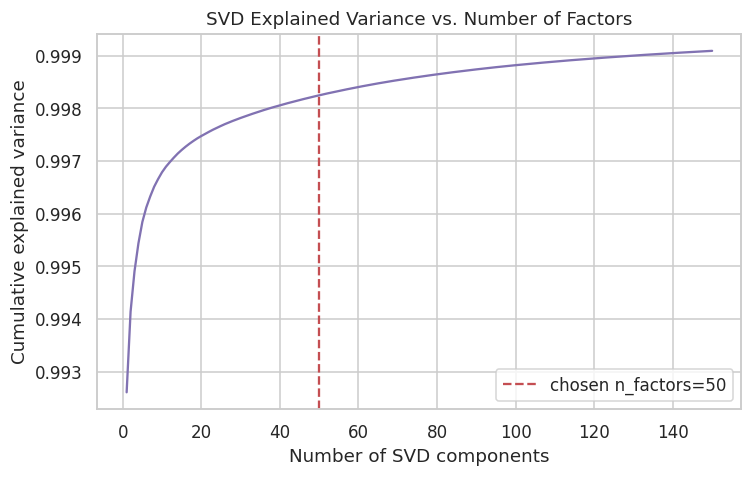

Variance explained at 50 factors: 99.8%


In [9]:
svd_probe = TruncatedSVD(n_components=min(150, cf_model.n_items - 1), random_state=42)
svd_probe.fit(cf_model.interaction_matrix)
cumvar = np.cumsum(svd_probe.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(np.arange(1, len(cumvar) + 1), cumvar, color="#8172B2")
ax.axvline(MODEL_CONFIG.svd_n_factors, color="#C44E52", linestyle="--",
           label=f"chosen n_factors={MODEL_CONFIG.svd_n_factors}")
ax.set_xlabel("Number of SVD components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("SVD Explained Variance vs. Number of Factors")
ax.legend()
plt.tight_layout()
plt.savefig(MODEL_ASSETS / "03_svd_explained_variance.png", bbox_inches="tight")
plt.show()

print(f"Variance explained at {MODEL_CONFIG.svd_n_factors} factors: {cumvar[MODEL_CONFIG.svd_n_factors-1]:.1%}")


## 4. Hybrid Recommendation



In [10]:
hybrid_model = HybridRecommender(popularity_model, content_model, cf_model,
                                   user_features, item_id_map, user_id_map)

# Scenario A: an established, active shopper
active_visitorid = int(user_id_map.loc[user_id_map["user_idx"] == active_user_idx, "visitorid"].iloc[0])
print(f"Scenario A — active shopper (visitorid={active_visitorid}):")
recs_active = hybrid_model.recommend(active_visitorid, n=5)
display(recs_active)
print(hybrid_model.explain(active_visitorid, int(recs_active.iloc[0]["itemid"])))


Scenario A — active shopper (visitorid=311):


,itemid,hybrid_score,cf_confidence_used
0,2901,0.600000,1.0
1,2859,0.569608,1.0
2,2909,0.560415,1.0
3,689,0.542411,1.0
4,2884,0.518264,1.0


Recommended based on your browsing and purchase history.


In [11]:
# Scenario B: a brand-new, never-seen visitor (cold start)
cold_visitorid = 999_999_999
print(f"Scenario B — brand-new visitor (visitorid={cold_visitorid}):")
recs_cold = hybrid_model.recommend(cold_visitorid, n=5)
display(recs_cold)
print(hybrid_model.explain(cold_visitorid, int(recs_cold.iloc[0]["itemid"])))


Scenario B — brand-new visitor (visitorid=999999999):


,itemid,hybrid_score,cf_confidence_used
0,23.0,0.15,0.0
1,3000.0,0.15,0.0
2,1.0,0.15,0.0
3,3.0,0.15,0.0
4,2.0,0.15,0.0


Recommended because it's popular among shoppers with similar interests.


In [12]:
# Scenario C: product-page context (seed_item_id) for the same cold visitor —
# powers a "Similar Products" rail even with zero visitor history.
seed_item = int(item_features.loc[item_features["item_view_count"] > 0, "itemid"].iloc[20])
print(f"Scenario C — product-page 'Similar Products' rail (seed_item_id={seed_item}):")
recs_seed = hybrid_model.recommend(cold_visitorid, n=5, seed_item_id=seed_item)
display(recs_seed)


Scenario C — product-page 'Similar Products' rail (seed_item_id=21):


,itemid,hybrid_score,cf_confidence_used
0,2477.0,0.25,0.0
1,2402.0,0.25,0.0
2,1610.0,0.25,0.0
3,127.0,0.25,0.0
4,540.0,0.25,0.0


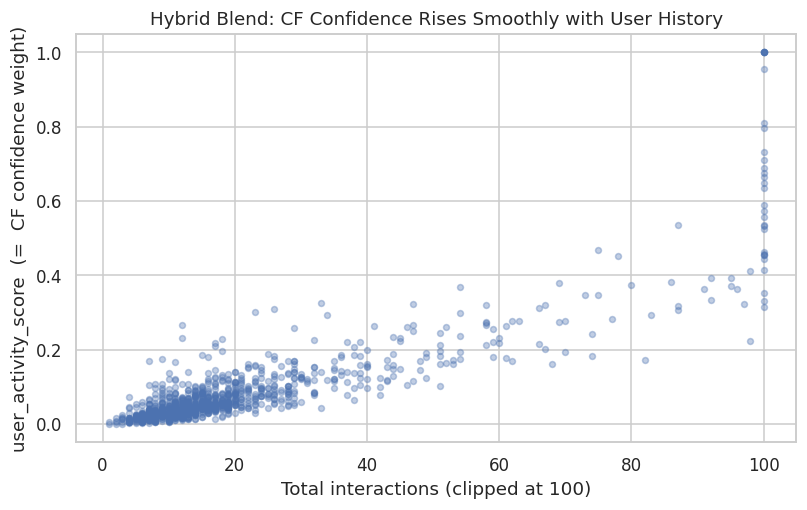

In [13]:
sample_users = user_features.sample(min(1000, len(user_features)), random_state=42)
total_interactions = (
    sample_users["user_view_count"] + sample_users["user_addtocart_count"] + sample_users["user_purchase_count"]
)

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.scatter(total_interactions.clip(upper=100), sample_users["user_activity_score"], alpha=0.35, s=15, color="#4C72B0")
ax.set_xlabel("Total interactions (clipped at 100)")
ax.set_ylabel("user_activity_score  (=  CF confidence weight)")
ax.set_title("Hybrid Blend: CF Confidence Rises Smoothly with User History")
plt.tight_layout()
plt.savefig(MODEL_ASSETS / "04_hybrid_confidence_scaling.png", bbox_inches="tight")
plt.show()



## 5. Persistence



In [14]:
train_and_save_all_models()
print("Models retrained and persisted to models/.")


2026-07-25 06:34:56 | INFO     | src.recommender | PopularityRecommender.fit completed in 0.00s


2026-07-25 06:34:56 | INFO     | src.recommender | ContentBasedRecommender: no usable brand column found (Retailrocket does not label one) — brand similarity is architecturally supported but inactive for this dataset.


2026-07-25 06:34:56 | INFO     | src.recommender | ContentBasedRecommender: fit TF-IDF over 3000 items, vocabulary size 126


2026-07-25 06:34:56 | INFO     | src.recommender | ContentBasedRecommender.fit completed in 0.13s


2026-07-25 06:34:56 | INFO     | src.recommender | CF interaction matrix: 3999 users x 1914 items, 39149 nonzero entries | 6 users and 522 items below the min-interaction threshold (excluded from CF, routed to hybrid fallback instead)


...

2026-07-25 06:34:56 | INFO     | src.recommender | FrequentlyBoughtTogetherRecommender: 6331 transactions -> 4169 baskets (1460 with >=2 items), 985 items have at least one co-purchase partner


2026-07-25 06:34:56 | INFO     | src.recommender | FrequentlyBoughtTogetherRecommender.fit completed in 0.16s


2026-07-25 06:34:56 | INFO     | src.recommender | Persisted popularity_model, content_model, cf_model, fbt_model to /home/claude/Ecommerce-Recommendation-System/models


2026-07-25 06:34:56 | INFO     | src.recommender | train_and_save_all_models completed in 0.76s


Models retrained and persisted to models/.
